In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True,
    dtype=int
)

In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [13]:
X = df.drop(columns=['Exited'])
y = df['Exited']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)

In [15]:
X.shape

(10000, 11)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [18]:
model = Sequential()

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-10-01 03:52:19.282492: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [21]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7459 - loss: 0.5536 - val_accuracy: 0.7975 - val_loss: 0.4834
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8003 - loss: 0.4633 - val_accuracy: 0.8081 - val_loss: 0.4417
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8141 - loss: 0.4318 - val_accuracy: 0.8144 - val_loss: 0.4185
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8273 - loss: 0.4134 - val_accuracy: 0.8244 - val_loss: 0.4032
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8370 - loss: 0.3972 - val_accuracy: 0.8344 - val_loss: 0.3867
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8434 - loss: 0.3829 - val_accuracy: 0.8450 - val_loss: 0.3732
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8502 - loss: 0.3714 - val_accuracy: 0.8519 - val_loss: 0.3634
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8505 - loss: 0.3633 - val_accu

In [22]:
model.layers[0].get_weights()

[array([[-0.35407498,  0.4568948 ,  0.23092328, -0.23592263,  0.01711237,
         -0.07790636, -0.10696121, -0.21924157,  0.23433276,  0.02274208,
          0.11093986],
        [ 0.36497018,  0.22088413, -0.5672807 , -0.12719095, -0.7128396 ,
          0.7355113 ,  0.9083349 , -0.64215064, -0.708988  , -0.06377236,
          0.29540366],
        [ 0.8152495 ,  0.0580423 , -0.4629658 ,  0.2567054 ,  0.16671528,
          0.00615182,  0.02608949, -0.02635786,  0.24527211, -0.25188193,
         -0.07629403],
        [ 0.22603266,  0.6309459 ,  0.471918  , -0.1467292 ,  0.54872036,
          0.06171606, -0.0488738 , -0.6191073 , -0.60987693,  0.41281348,
         -0.49902347],
        [ 0.0409547 ,  0.37956968, -0.23486328,  1.0889506 , -0.32695955,
         -0.9771098 ,  1.2690115 ,  0.25779587, -0.67327875,  0.6153197 ,
         -0.35177225],
        [ 0.63144034,  0.28121138,  0.19582503,  0.25987774,  0.32663885,
          0.20415676,  0.10206322,  0.09256232,  0.4070038 , -0.0187316

In [23]:
model.layers[1].get_weights()

[array([[ 5.45192778e-01, -4.38546151e-01, -8.35251510e-02,
          1.23310290e-01, -2.22578794e-01, -5.35825431e-01,
          3.57252806e-02,  8.37747335e-01,  3.85836959e-01,
          2.83347309e-01, -7.04891756e-02],
        [ 8.13811794e-02, -5.98043859e-01, -9.90183651e-02,
         -5.79759061e-01,  2.47031346e-01, -3.35045367e-01,
         -4.09811884e-01, -5.10087945e-02,  1.04520671e-01,
          3.72409105e-01, -1.16993642e+00],
        [ 7.11527705e-01,  9.62633872e-04,  3.70081872e-01,
         -3.09657097e-01, -5.03276944e-01, -2.45057940e-01,
         -1.12948626e-01, -6.30280793e-01,  3.24247837e-01,
          3.01121235e-01, -5.01690283e-02],
        [-3.98671597e-01, -7.39896894e-01, -9.72845674e-01,
          1.26661867e-01,  7.99527645e-01,  2.47982487e-01,
         -9.18911099e-02,  2.00012445e-01, -3.78377169e-01,
         -2.59997904e-01, -3.44340414e-01],
        [ 1.63880929e-01, -7.78776586e-01, -8.40607509e-02,
          1.21865772e-01, -4.03370738e-01,  

In [24]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
y_pred = np.where(y_log>0.5, 1, 0)

In [26]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.864

In [28]:
import matplotlib.pyplot as plt

In [29]:
history.history

{'accuracy': [0.7459375262260437,
  0.8003125190734863,
  0.8140624761581421,
  0.827343761920929,
  0.8370312452316284,
  0.8434374928474426,
  0.8501562476158142,
  0.8504687547683716,
  0.8560937643051147,
  0.8575000166893005,
  0.8607812523841858,
  0.8603125214576721,
  0.8621875047683716,
  0.8617187738418579,
  0.8628125190734863,
  0.8621875047683716,
  0.8635937571525574,
  0.8629687428474426,
  0.8620312213897705,
  0.8639062643051147,
  0.862500011920929,
  0.86328125,
  0.8631250262260437,
  0.8650000095367432,
  0.8646875023841858,
  0.864062488079071,
  0.8643749952316284,
  0.8646875023841858,
  0.8642187714576721,
  0.8642187714576721,
  0.8660937547683716,
  0.8648437261581421,
  0.8653125166893005,
  0.8656250238418579,
  0.8667187690734863,
  0.8645312786102295,
  0.8670312762260437,
  0.8656250238418579,
  0.8678125143051147,
  0.864062488079071,
  0.8662499785423279,
  0.8645312786102295,
  0.8670312762260437,
  0.8667187690734863,
  0.8665624856948853,
  0.865156

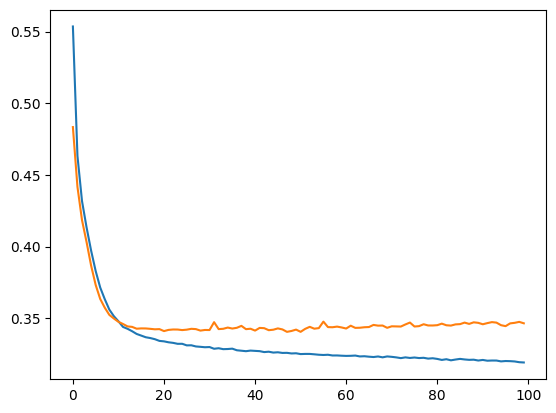

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])



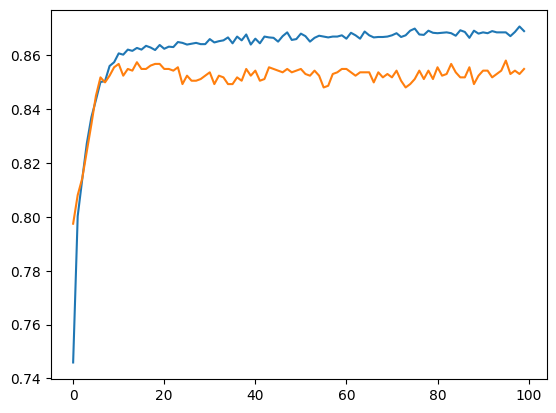

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
